In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
d = pd.read_csv("combined.csv")
s = pd.read_csv("summary.csv")

In [4]:
d["START"] = d["DISTRICT"].apply(lambda s: s.replace(" ", ""))
d["END"] = d["NEXT_DISTRICT"].apply(lambda s: s.replace(" ", ""))
d = d.drop(columns=["DISTRICT", "NEXT_DISTRICT"])
d["TRANSPORT"] = d["TRANSPORT"].factorize()[0]

In [5]:
d = pd.merge(d, s, on=["START", "END"], how="inner")

In [6]:
d = d.drop(columns=["START", "END", "COUNT", "DISTANCE_MEAN", "NUM_OF_STOPS_MEAN", "FARE_MEAN"])

In [7]:
d.corr()["PRICE"].drop("PRICE")

TRANSPORT                    -0.020408
NO_STOPS                      0.069098
DISTANCE                      0.490777
START_POPULATION/10000       -0.053995
START_EMPLOYED/10000          0.010980
START_POPULATION/AREA        -0.093882
START_AREA                    0.186228
START_DENSITY*10000          -0.111671
START_DENSITY_UNIQUE*10000   -0.136174
END_POPULATION/10000         -0.024251
END_EMPLOYED/10000            0.001865
END_POPULATION/AREA          -0.102349
END_AREA                      0.212319
END_DENSITY*10000            -0.114216
END_DENSITY_UNIQUE*10000     -0.143215
Name: PRICE, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

X = d.drop(columns=["PRICE"])
y = d["PRICE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# No filter

In [59]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

reg = SGDRegressor(loss="epsilon_insensitive")
reg.fit(X_train_scaled, y_train)
pred = reg.predict(X_test_scaled)

In [60]:
pred_df = pd.DataFrame({"Prediction": pred, "Ground Truth": y_test})

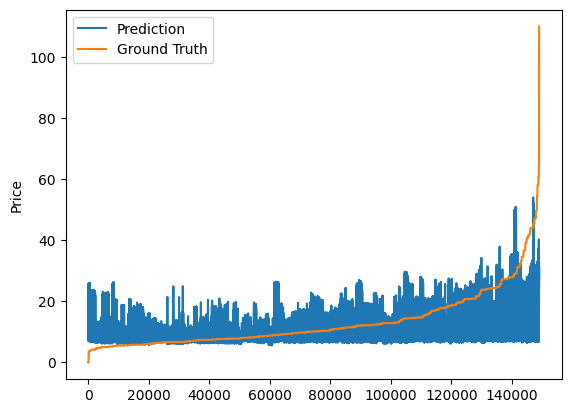

In [61]:
pred_df.sort_values("Ground Truth", ignore_index=True).plot()
plt.ylabel("Price")
plt.show()

In [33]:
from sklearn.metrics import r2_score

print(r2_score(y_test, pred))

0.08917761960560833


# Filter (quantile)

In [34]:
distance_upper80 = d["DISTANCE"].quantile(0.8)
distance_lower10 = d["DISTANCE"].quantile(0.1)
fare_upper90 = d["PRICE"].quantile(0.9)
fare_lower1 = d["PRICE"].quantile(0.01)
f = d[(d["DISTANCE"] >= distance_lower10) & (d["DISTANCE"] <= distance_upper80) & (d["PRICE"] <= fare_upper90) & (d["PRICE"] >= fare_lower1)]
f.corr()["PRICE"]

TRANSPORT                    -0.015553
NO_STOPS                     -0.027409
DISTANCE                      0.316086
PRICE                         1.000000
START_POPULATION/10000       -0.038178
START_EMPLOYED/10000          0.033760
START_POPULATION/AREA        -0.052431
START_AREA                    0.061338
START_DENSITY*10000          -0.013865
START_DENSITY_UNIQUE*10000   -0.051348
END_POPULATION/10000         -0.002453
END_EMPLOYED/10000            0.021228
END_POPULATION/AREA          -0.035274
END_AREA                      0.047738
END_DENSITY*10000            -0.016319
END_DENSITY_UNIQUE*10000     -0.043521
Name: PRICE, dtype: float64

In [35]:
from sklearn.model_selection import train_test_split

X = f.drop(columns=["PRICE"])
y = f["PRICE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

reg = SGDRegressor(loss="epsilon_insensitive")
reg.fit(X_train_scaled, y_train)
pred = reg.predict(X_test_scaled)

In [38]:
pred_df = pd.DataFrame({"Prediction": pred, "Ground Truth": y_test})

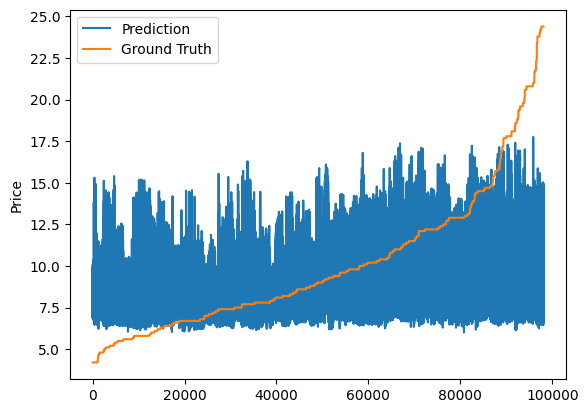

In [39]:
pred_df.sort_values("Ground Truth", ignore_index=True).plot()
plt.ylabel("Price")
plt.show()

In [40]:
from sklearn.metrics import r2_score

print(r2_score(y_test, pred))

0.09242032430203118


# NN

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

os.environ["OMP_NUM_THREADS"] = "8"
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

In [56]:
X_train_s, X_val, y_train_s, y_val = train_test_split(X_train_scaled, y_train, test_size=0.05, random_state=42)

model = keras.Sequential([
    layers.Input(shape=(len(X_train.columns),)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

In [57]:
model.fit(X_train_s, y_train_s, epochs=60, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 54.8914 - val_loss: 44.7307
Epoch 2/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 43.1449 - val_loss: 41.5488
Epoch 3/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 40.5642 - val_loss: 39.9974
Epoch 4/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 39.3690 - val_loss: 39.9295
Epoch 5/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 37.7539 - val_loss: 37.5009
Epoch 6/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 37.1222 - val_loss: 37.2618
Epoch 7/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 36.1428 - val_loss: 36.8371
Epoch 8/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 35.6767 - val_loss: 36.1591
Epoch 9/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - loss: 35.2542 - val_loss: 36.4810
Epoch 10/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - loss: 35.1694 - val_loss: 35.3212
Epoch 11/60
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 34.

In [59]:
from sklearn.metrics import r2_score

pred = model.predict(X_test_scaled)
print(r2_score(y_test, pred))

4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 982us/step
0.632704601673769


In [60]:
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_train_s, model.predict(X_train_s)))
print(mean_squared_error(y_test, pred))

10319/10319 ━━━━━━━━━━━━━━━━━━━━ 10s 994us/step
27.98573553432118
29.625971415346847


# NN (feature selection)

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

os.environ["OMP_NUM_THREADS"] = "8"
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

In [95]:
from sklearn.preprocessing import StandardScaler

features = [
    "TRANSPORT",
    "DISTANCE",
    "START_POPULATION/AREA",
    "START_EMPLOYED/10000",
    "START_DENSITY_UNIQUE*10000",
    "END_POPULATION/AREA",
    "END_EMPLOYED/10000",
    "END_DENSITY_UNIQUE*10000",
]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_s, X_val, y_train_s, y_val = train_test_split(X_train_scaled, y_train, test_size=0.05, random_state=42)

In [96]:
model = keras.Sequential([
    layers.Input(shape=(len(X_train.columns),)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

In [100]:
model.fit(X_train_s, y_train_s, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.2793 - val_loss: 31.1391
Epoch 2/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.5544 - val_loss: 30.7443
Epoch 3/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.4114 - val_loss: 29.9526
Epoch 4/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.3372 - val_loss: 30.0615
Epoch 5/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.5224 - val_loss: 30.4921
Epoch 6/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 28.3890 - val_loss: 30.5908
Epoch 7/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 27.9335 - val_loss: 30.5848
Epoch 8/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 28.2307 - val_loss: 30.3740
Epoch 9/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 27.9703 - val_loss: 30.6534
Epoch 10/10
10319/10319 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 28.1115 - val_loss: 30.4122


In [101]:
from sklearn.metrics import r2_score

pred = model.predict(X_test_scaled)
print(r2_score(y_test, pred))

4655/4655 ━━━━━━━━━━━━━━━━━━━━ 4s 932us/step
0.6351170941589768


In [102]:
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_train_s, model.predict(X_train_s)))
print(mean_squared_error(y_test, pred))

10319/10319 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
27.94496410005154
29.431380266826594


# NN (filtered) (feature selected)

In [103]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

os.environ["OMP_NUM_THREADS"] = "8"
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = [
    "TRANSPORT",
    "DISTANCE",
    "START_POPULATION/AREA",
    "START_EMPLOYED/10000",
    "START_DENSITY_UNIQUE*10000",
    "END_POPULATION/AREA",
    "END_EMPLOYED/10000",
    "END_DENSITY_UNIQUE*10000",
]

distance_upper80 = d["DISTANCE"].quantile(0.8)
distance_lower10 = d["DISTANCE"].quantile(0.1)
fare_upper90 = d["PRICE"].quantile(0.9)
fare_lower1 = d["PRICE"].quantile(0.01)
f = d[(d["DISTANCE"] >= distance_lower10) & (d["DISTANCE"] <= distance_upper80) & (d["PRICE"] <= fare_upper90) & (d["PRICE"] >= fare_lower1)]

X = f.drop(columns=["PRICE"])
y = f["PRICE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_s, X_val, y_train_s, y_val = train_test_split(X_train_scaled, y_train, test_size=0.05, random_state=42)

In [105]:
model = keras.Sequential([
    layers.Input(shape=(len(X_train.columns),)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

In [124]:
model.fit(X_train_s, y_train_s, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.9100 - val_loss: 7.1253
Epoch 2/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8505 - val_loss: 7.3205
Epoch 3/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8110 - val_loss: 7.1242
Epoch 4/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8542 - val_loss: 7.1603
Epoch 5/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8982 - val_loss: 7.1331
Epoch 6/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8794 - val_loss: 7.1702
Epoch 7/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.7825 - val_loss: 7.0498
Epoch 8/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8175 - val_loss: 7.0216
Epoch 9/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 6.8794 - val_loss: 7.0280
Epoch 10/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 6.8039 - val_loss: 7.0034
Epoch 11/20
6795/6795 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 6.8595 - val_loss: 7.0880
Epoch 12/20
6795/67

In [125]:
from sklearn.metrics import r2_score

pred = model.predict(X_test_scaled)
print(r2_score(y_test, pred))

3066/3066 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
0.5868263262624285


In [126]:
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_train_s, model.predict(X_train_s)))
print(mean_squared_error(y_test, pred))

6795/6795 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
6.788975606828639
7.395679105587784


# Kelly dataset

In [8]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score

tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(8)

# Read the CSV files (adjust file paths as needed)
d = pd.read_csv("filtered_data.csv").dropna()

In [9]:
# Preprocess the data
# d["TRANSPORT"] = d["TRANSPORT"].factorize()[0]
transport = pd.get_dummies(d["TRANSPORT"])

features = [
    'DISTANCE',
    'PASS HARBOUR',
    'STOP_COUNT', 'STOP_COUNT_UNIQUE',
    'AREA',
    'DENSITY_UNIQUE*100000',
    'LIVING POPULATION', 'WORKING POPULATION',
    'BUILDING NUMBER', 'ESTIMATED EMPLOYED POPULATION', 'MEDIAN MONTHLY INCOME',
    'NEXT STOP_COUNT', 'NEXT STOP_COUNT_UNIQUE',
    'NEXT AREA',
    'NEXT DENSITY_UNIQUE*100000',
    'NEXT LIVING POPULATION', 'NEXT WORKING POPULATION',
    'NEXT BUILDING NUMBER',
    'NEXT ESTIMATED EMPLOYED POPULATION',
    'NEXT MEDIAN MONTHLY INCOME'
]

# Prepare features and target
X = d[features].join(transport)
y = d["PRICE"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Further split the training data into training and validation sets
X_train_s, X_val, y_train_s, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

In [10]:
# Define the neural network model with updated units starting from 512
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # Input shape based on number of features
    layers.Dense(512, activation='relu'),            # Hidden layer 1: 512 units
    layers.Dense(256, activation='relu'),            # Hidden layer 2: 256 units
    layers.Dense(128, activation='relu'),            # Hidden layer 3: 128 units
    layers.Dense(64, activation='relu'),             # Hidden layer 4: 64 units
    layers.Dense(32, activation='relu'),             # Hidden layer 5: 32 units
    layers.Dense(1)                                  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [11]:
# Train the model and store training history
history = model.fit(X_train_s, y_train_s,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 75s 3ms/step - loss: 30.1688 - val_loss: 24.7658
Epoch 2/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - loss: 24.2934 - val_loss: 23.6969
Epoch 3/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - loss: 23.8123 - val_loss: 23.2603
Epoch 4/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 23.4356 - val_loss: 23.2460
Epoch 5/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - loss: 23.2421 - val_loss: 23.0244
Epoch 6/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - loss: 23.0560 - val_loss: 23.4795
Epoch 7/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - loss: 23.0305 - val_loss: 22.8067
Epoch 8/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 66s 2ms/step - loss: 22.8750 - val_loss: 22.8716
Epoch 9/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 65s 2ms/step - loss: 22.8616 - val_loss: 22.7269
Epoch 10/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 62s 2ms/step - loss: 22.7803 - val_loss: 22.7794
Epoch 11/30
26519/26519 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 22.

14207/14207 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
R² Score on Test Set: 0.6630515392749758


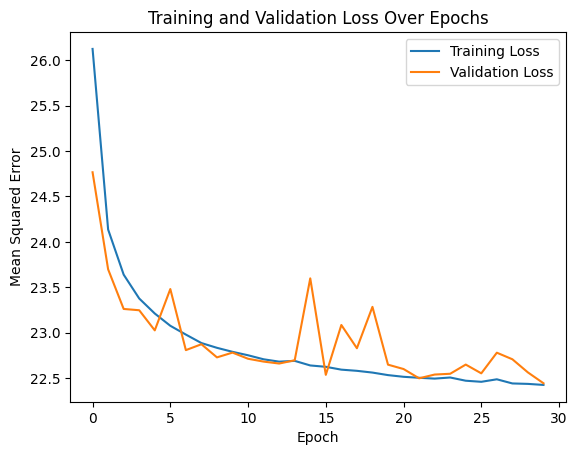

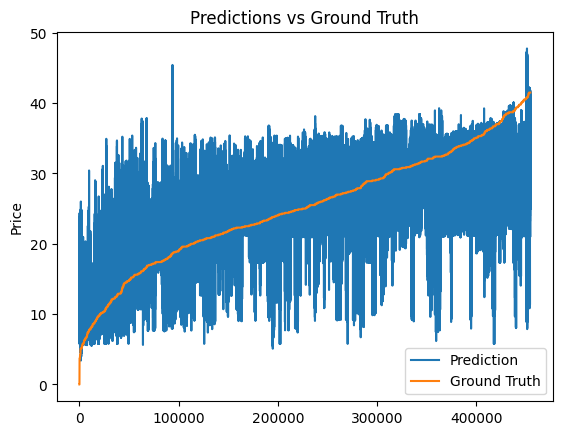

In [12]:
# Make predictions on the test set
pred = model.predict(X_test_scaled).flatten()  # Flatten to match y_test shape

# Evaluate the model
r2 = r2_score(y_test, pred)
print(f"R² Score on Test Set: {r2}")

# Visualize training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

# Visualize predictions vs ground truth
pred_df = pd.DataFrame({"Prediction": pred, "Ground Truth": y_test.values})
pred_df.sort_values("Ground Truth", ignore_index=True).plot()
plt.ylabel("Price")
plt.title("Predictions vs Ground Truth")
plt.show()

# Neural attempt 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import keras_hub

In [40]:
d = pd.read_csv("../final_transport_data.csv").dropna()

In [41]:
transport = pd.get_dummies(d["TRANSPORT"])

features = [
    'DISTANCE',
    'PASS HARBOUR',
    'STOP_COUNT', 'STOP_COUNT_UNIQUE',
    'AREA',
    'DENSITY_UNIQUE*100000',
    'LIVING POPULATION', 'WORKING POPULATION',
    'BUILDING NUMBER', 'ESTIMATED EMPLOYED POPULATION', 'MEDIAN MONTHLY INCOME',
    'NEXT STOP_COUNT', 'NEXT STOP_COUNT_UNIQUE',
    'NEXT AREA',
    'NEXT DENSITY_UNIQUE*100000',
    'NEXT LIVING POPULATION', 'NEXT WORKING POPULATION',
    'NEXT BUILDING NUMBER',
    'NEXT ESTIMATED EMPLOYED POPULATION',
    'NEXT MEDIAN MONTHLY INCOME'
]

# Prepare features and target
X = d[features].join(transport)
y = d["PRICE"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Further split the training data into training and validation sets
X_train_s, X_val, y_train_s, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

In [5]:
# Define the neural network model with updated units starting from 512
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(1024, activation='relu'),
    layers.Dense(640, activation='relu'),    
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=["r2_score"],)

In [6]:
history = model.fit(X_train_s, y_train_s,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - loss: 21.5148 - r2_score: 0.7353 - val_loss: 18.9462 - val_r2_score: 0.7671
Epoch 2/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 17.6153 - r2_score: 0.7831 - val_loss: 17.9529 - val_r2_score: 0.7793
Epoch 3/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - loss: 17.1320 - r2_score: 0.7889 - val_loss: 17.4114 - val_r2_score: 0.7860
Epoch 4/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 16.7439 - r2_score: 0.7940 - val_loss: 16.9477 - val_r2_score: 0.7917
Epoch 5/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 16.6403 - r2_score: 0.7952 - val_loss: 16.8780 - val_r2_score: 0.7925
Epoch 6/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss: 16.4493 - r2_score: 0.7975 - val_loss: 16.6825 - val_r2_score: 0.7949
Epoch 7/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 16.3285 - r2_score: 0.7990 - val_loss: 16.6795 - val_r2_score: 0.7950
Epoch 8/50
23661/23661 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/ste

R² Score on Test Set: 0.806287985651044


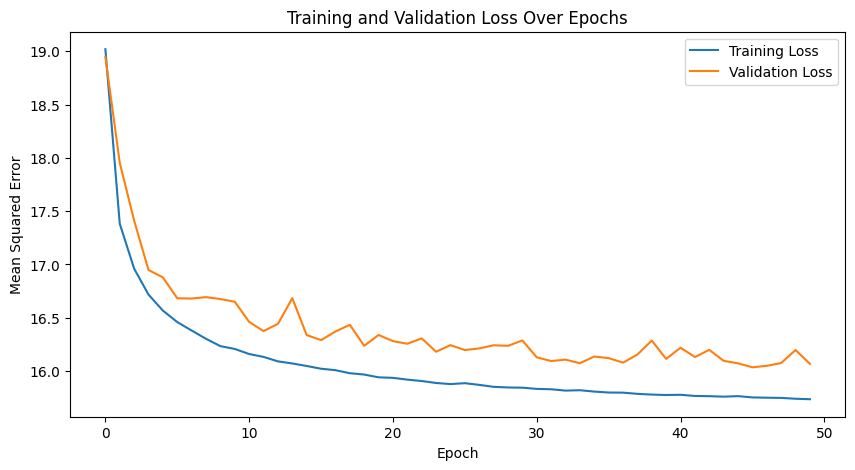

<Figure size 1000x500 with 0 Axes>

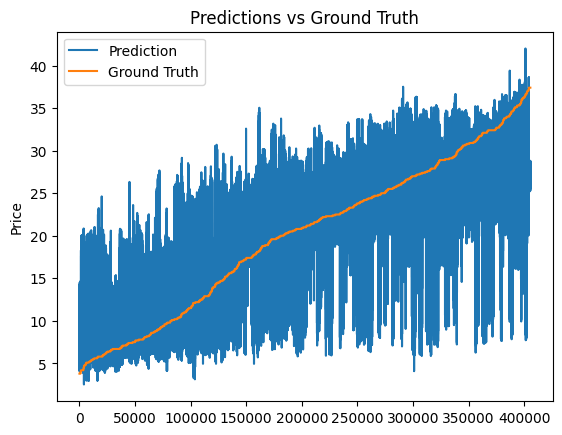

In [44]:
# Make predictions on the test set
# pred = model.predict(X_test_scaled).flatten()  # Flatten to match y_test shape

# Evaluate the model
r2 = r2_score(y_test, pred)
print(f"R² Score on Test Set: {r2}")

# Visualize training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.savefig("NN_training_loss.png")

# Visualize predictions vs ground truth
pred_df = pd.DataFrame({"Prediction": pred, "Ground Truth": y_test.values})
plt.figure(figsize=(10, 5))
pred_df.sort_values("Ground Truth", ignore_index=True).plot()
plt.ylabel("Price")
plt.title("Predictions vs Ground Truth")
plt.savefig("NN_pred_vs_truth.png")

In [8]:
model.save("nn.keras")

# Random Forest and Cross Validation

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv('../final_transport_data.csv')

In [12]:
response_var = 'PRICE'
explanatory_vars = [
    'TRANSPORT',
    'NO_STOPS',
    'DISTANCE',
    'STOP_COUNT',
    'STOP_COUNT_UNIQUE',
    'AREA',
    'DENSITY_UNIQUE',
    'LIVING POPULATION',
    'WORKING POPULATION',
    'BUILDING NUMBER',
    'ESTIMATED EMPLOYED POPULATION',
    'MEDIAN MONTHLY INCOME',
    'NEXT STOP_COUNT',
    'NEXT STOP_COUNT_UNIQUE',
    'NEXT AREA',
    'NEXT DENSITY_UNIQUE',
    'NEXT DENSITY_UNIQUE*100000',
    'NEXT LIVING POPULATION',
    'NEXT WORKING POPULATION',
    'NEXT BUILDING NUMBER',
    'NEXT ESTIMATED EMPLOYED POPULATION',
    'NEXT MEDIAN MONTHLY INCOME',
    'PASS HARBOUR'
]

# Clean data
data = data.dropna(axis=0)

# 2. Feature Engineering
X = data[explanatory_vars]
y = data[response_var]

In [13]:
if 'TRANSPORT' in X.columns:
    X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])
    print(f"Transport categories: {list(transport_categories)}")

# Convert other categorical variables (if any) to dummy variables
X = pd.get_dummies(X, drop_first=True)

Transport categories: ['BUS', 'MINIBUS', 'MTR', 'BUS->BUS', 'MINIBUS->BUS', 'MTR->MINIBUS', 'MTR->BUS', 'BUS->MINIBUS', 'MINIBUS->MTR', 'BUS->MTR']


/tmp/ipykernel_77928/1072448171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['TRANSPORT'], transport_categories = pd.factorize(X['TRANSPORT'])


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

In [16]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
y_pred = rf.predict(X_test)

metrics = {
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

MSE: 11.1354
RMSE: 3.3370
MAE: 2.1092
R2: 0.8630


<Axes: >

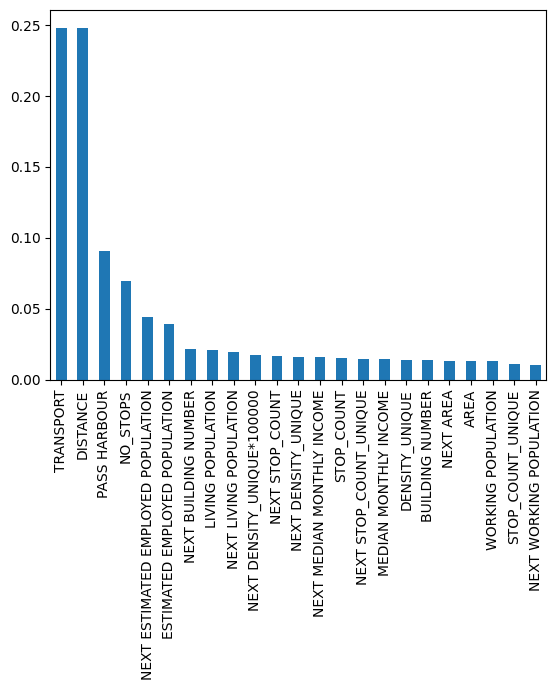

In [18]:
forest_importances = pd.Series(rf.feature_importances_, index=explanatory_vars).sort_values(ascending=False)
forest_importances.plot.bar()

In [19]:
test_set = X_test
test_set["DISTRICT"] = data.loc[test_set.index]["DISTRICT"]
test_set["NEXT DISTRICT"] = data.loc[test_set.index]["NEXT DISTRICT"]
test_set["pred"] = y_pred
test_set["truth"] = y_test

In [20]:
r2_by_district = test_set.groupby("DISTRICT")[["pred", "truth"]].apply(lambda x: r2_score(x["truth"], x["pred"]))
mse_by_district = test_set.groupby("DISTRICT")[["pred", "truth"]].apply(lambda x: mean_squared_error(x["truth"], x["pred"]))

Text(0.5, 1.0, 'R^2 for each starting constituency')

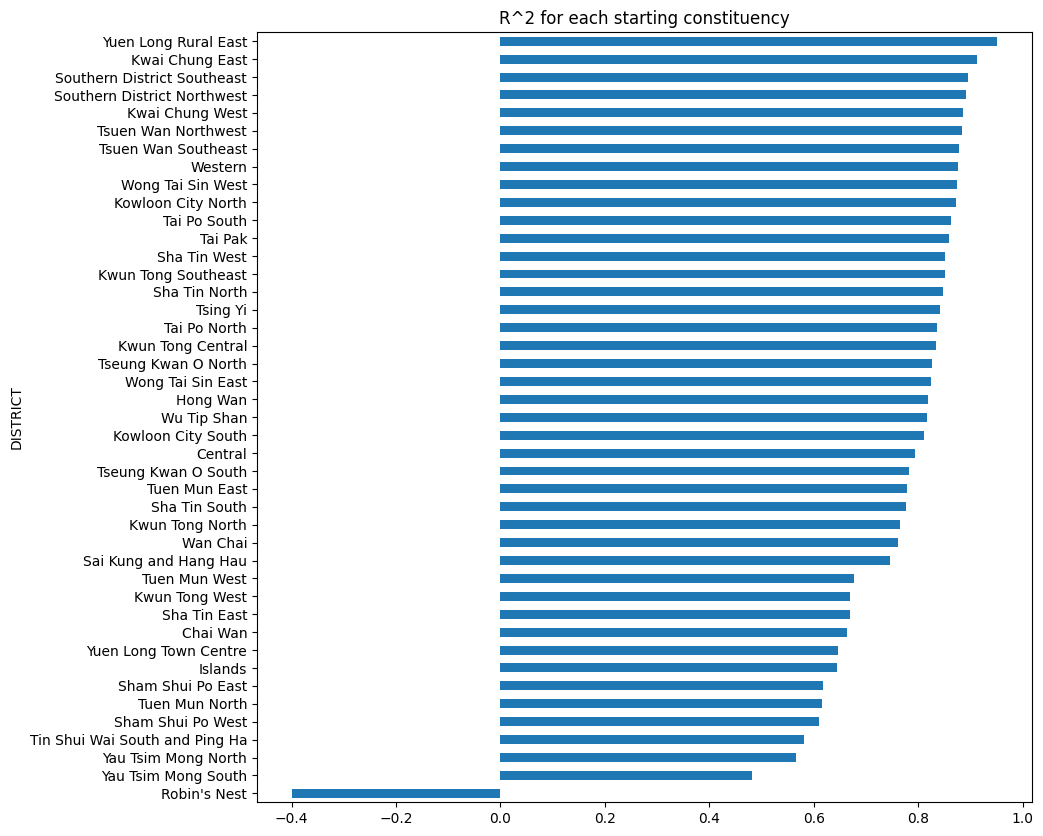

In [21]:
t = r2_by_district.sort_values()
plt.figure(figsize=(10, 10))
t.plot.barh()
plt.title("R^2 for each starting constituency")

In [22]:
one_hot_t = pd.get_dummies(data["TRANSPORT"])
new_data = data.join(one_hot_t)
new_data["TRANSPORT"] = pd.factorize(new_data["TRANSPORT"])[0]
sampled_data = new_data.sample(200000, random_state=42)

In [23]:
y_val = sampled_data["PRICE"]

x_val_rf = sampled_data[explanatory_vars]

x_val_nn = sampled_data[features + list(one_hot_t.columns)]

In [24]:
y_pred_rf = rf.predict(x_val_rf).flatten()
y_pred_nn = model.predict(scaler.transform(x_val_nn)).flatten()

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


In [27]:
diff_rf = (y_pred_rf - y_val) / y_val
diff_rf = diff_rf[(diff_rf >= diff_rf.quantile(0.1)) & (diff_rf <= diff_rf.quantile(0.9))]
diff_nn = (y_pred_nn - y_val) / y_val
diff_nn = diff_nn[(diff_nn >= diff_nn.quantile(0.1)) & (diff_nn <= diff_nn.quantile(0.9))]

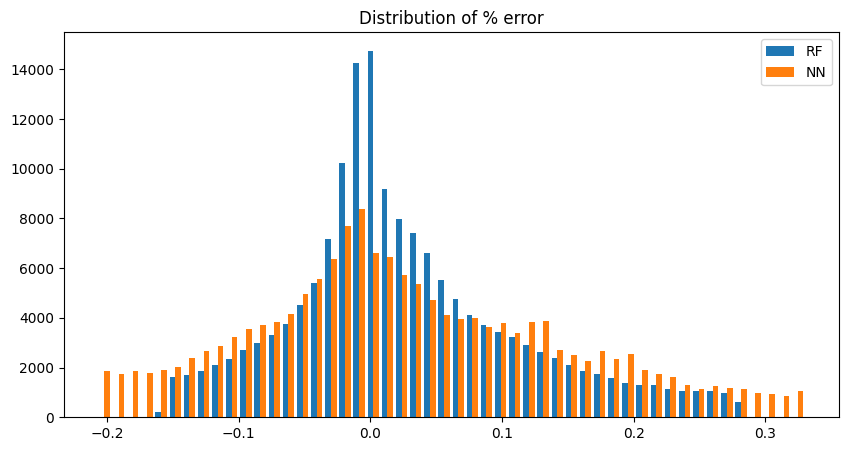

In [37]:
plt.figure(figsize=(10, 5))
plt.hist([diff_rf, diff_nn], bins=50, label=["RF", "NN"])
plt.legend()
plt.title("Distribution of % error")
plt.savefig("distribution_percentage_error.png")

/tmp/ipykernel_77928/457819620.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v.groupby("DISTRICT").apply(lambda x: x["diff"].mean()).sort_values().plot.bar()


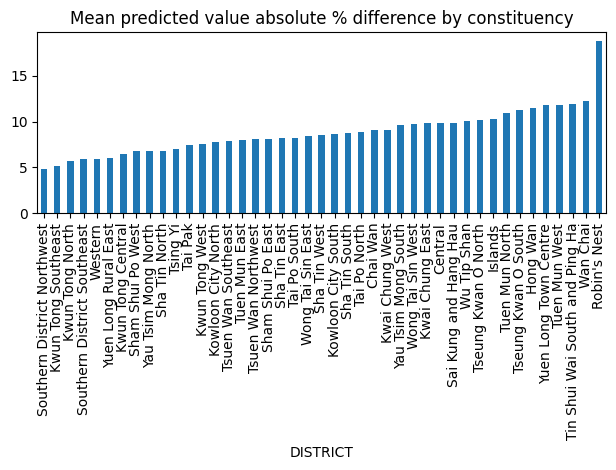

In [33]:
v = sampled_data
v["diff"] = abs(y_pred_rf - y_pred_nn) / y_val * 100

v.groupby("DISTRICT").apply(lambda x: x["diff"].mean()).sort_values().plot.bar()
plt.title("Mean predicted value absolute % difference by constituency")
plt.tight_layout()
plt.savefig("mean_predicted_value_diffs.png")

In [30]:
v.groupby("DISTRICT").apply(lambda x: x["diff"].mean()).sort_values()

/tmp/ipykernel_77928/698971869.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  v.groupby("DISTRICT").apply(lambda x: x["diff"].mean()).sort_values()


DISTRICT
Southern District Northwest        4.878997
Kwun Tong Southeast                5.098502
Kwun Tong North                    5.699734
Southern District Southeast        5.902948
Western                            5.912480
Yuen Long Rural East               6.003863
Kwun Tong Central                  6.447653
Sham Shui Po West                  6.802563
Yau Tsim Mong North                6.821948
Sha Tin North                      6.833401
Tsing Yi                           7.040100
Tai Pak                            7.398755
Kwun Tong West                     7.610303
Kowloon City North                 7.739460
Tsuen Wan Southeast                7.904566
Tuen Mun East                      8.027291
Tsuen Wan Northwest                8.072787
Sham Shui Po East                  8.090997
Sha Tin East                       8.183626
Tai Po South                       8.196723
Wong Tai Sin East                  8.394697
Sha Tin West                       8.576566
Kowloon City South     

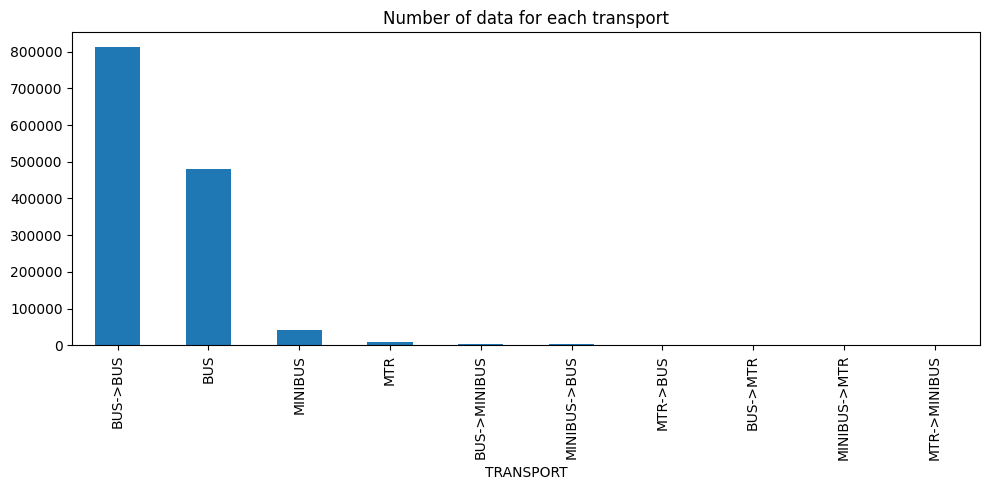

In [49]:
plt.figure(figsize=(10, 5))
data["TRANSPORT"].value_counts().plot.bar()
plt.title("Number of data for each transport")
plt.tight_layout()
plt.savefig("data_per_transport.png")